## Hallazgos de Privacidad

- Se identificaron múltiples campos clasificados como datos sensibles, incluyendo:
  - Medical Condition
  - Medication
  - Test Results
  - Blood Type

- Existen datos personales directos que permiten identificar individuos.

- La combinación de cuasi identificadores (edad, género) con datos sensibles incrementa el riesgo de reidentificación.

- Se identifican datos financieros que también representan riesgo adicional.

### Conclusión

El dataset presenta un nivel de riesgo medio-alto desde una perspectiva de privacidad, por lo que se recomienda aplicar controles como:
- enmascaramiento de datos
- anonimización
- control de accesos

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../images", exist_ok=True)

classification_df = pd.read_csv("../data/processed/privacy_classification.csv")
df = pd.read_csv("../data/processed/healthcare_eda_processed.csv")

classification_df.head()

,Campo,Tipo de Dato,Nivel Riesgo
0,Name,Personal Directo,5.0
1,Age,Cuasi Identificador,4.0
2,Gender,Cuasi Identificador,4.0
3,Blood Type,Dato Sensible,5.0
4,Medical Condition,Dato Sensible,5.0


In [3]:
classification_df

,Campo,Tipo de Dato,Nivel Riesgo
0,Name,Personal Directo,5.0
1,Age,Cuasi Identificador,4.0
2,Gender,Cuasi Identificador,4.0
3,Blood Type,Dato Sensible,5.0
4,Medical Condition,Dato Sensible,5.0
5,Date of Admission,Dato Operacional,2.0
6,Doctor,Dato Personal,NaN
7,Hospital,Dato Operacional,2.0
8,Insurance Provider,Dato Financiero,4.0
9,Billing Amount,Dato Financiero,4.0


In [5]:
classification_df["Tipo de Dato"].unique()

<StringArray>
[   'Personal Directo', 'Cuasi Identificador',       'Dato Sensible',
    'Dato Operacional',       'Dato Personal',     'Dato Financiero',
       'Dato Derivado']
Length: 7, dtype: str

In [6]:
# ==============================
# Agregar dimensiones de riesgo
# ==============================

# Limpiar posibles espacios en los textos
classification_df["Tipo de Dato"] = classification_df["Tipo de Dato"].str.strip()

risk_dimensions = {
    "Personal Directo": {
        "Sensibilidad": 5,
        "Exposicion": 5,
        "Impacto": 5,
        "Probabilidad": 4
    },
    "Dato Personal": {
        "Sensibilidad": 5,
        "Exposicion": 4,
        "Impacto": 5,
        "Probabilidad": 4
    },
    "Dato Sensible": {
        "Sensibilidad": 5,
        "Exposicion": 4,
        "Impacto": 5,
        "Probabilidad": 4
    },
    "Cuasi Identificador": {
        "Sensibilidad": 4,
        "Exposicion": 4,
        "Impacto": 4,
        "Probabilidad": 3
    },
    "Dato Financiero": {
        "Sensibilidad": 4,
        "Exposicion": 3,
        "Impacto": 4,
        "Probabilidad": 3
    },
    "Dato Operacional": {
        "Sensibilidad": 2,
        "Exposicion": 2,
        "Impacto": 2,
        "Probabilidad": 2
    },
    "Dato Derivado": {
        "Sensibilidad": 1,
        "Exposicion": 2,
        "Impacto": 2,
        "Probabilidad": 1
    }
}

risk_df = classification_df.copy()

risk_df["Sensibilidad"] = risk_df["Tipo de Dato"].map(lambda x: risk_dimensions[x]["Sensibilidad"])
risk_df["Exposicion"] = risk_df["Tipo de Dato"].map(lambda x: risk_dimensions[x]["Exposicion"])
risk_df["Impacto"] = risk_df["Tipo de Dato"].map(lambda x: risk_dimensions[x]["Impacto"])
risk_df["Probabilidad"] = risk_df["Tipo de Dato"].map(lambda x: risk_dimensions[x]["Probabilidad"])

risk_df.head()

,Campo,Tipo de Dato,Nivel Riesgo,Sensibilidad,Exposicion,Impacto,Probabilidad
0,Name,Personal Directo,5.0,5,5,5,4
1,Age,Cuasi Identificador,4.0,4,4,4,3
2,Gender,Cuasi Identificador,4.0,4,4,4,3
3,Blood Type,Dato Sensible,5.0,5,4,5,4
4,Medical Condition,Dato Sensible,5.0,5,4,5,4


In [7]:
# ==============================
# Calcular score de riesgo
# ==============================

risk_df["Risk Score"] = (
    risk_df["Sensibilidad"] *
    risk_df["Exposicion"] *
    risk_df["Impacto"] *
    risk_df["Probabilidad"]
)

risk_df.sort_values(by="Risk Score", ascending=False)

,Campo,Tipo de Dato,Nivel Riesgo,Sensibilidad,Exposicion,Impacto,Probabilidad,Risk Score
0,Name,Personal Directo,5.0,5,5,5,4,500
3,Blood Type,Dato Sensible,5.0,5,4,5,4,400
6,Doctor,Dato Personal,NaN,5,4,5,4,400
4,Medical Condition,Dato Sensible,5.0,5,4,5,4,400
13,Medication,Dato Sensible,5.0,5,4,5,4,400
14,Test Results,Dato Sensible,5.0,5,4,5,4,400
2,Gender,Cuasi Identificador,4.0,4,4,4,3,192
1,Age,Cuasi Identificador,4.0,4,4,4,3,192
8,Insurance Provider,Dato Financiero,4.0,4,3,4,3,144
9,Billing Amount,Dato Financiero,4.0,4,3,4,3,144


In [8]:
# ==============================
# Clasificar nivel de riesgo
# ==============================

def classify_risk(score):
    if score >= 400:
        return "Crítico"
    elif score >= 250:
        return "Alto"
    elif score >= 100:
        return "Medio"
    else:
        return "Bajo"

risk_df["Nivel de Riesgo"] = risk_df["Risk Score"].apply(classify_risk)

risk_df.sort_values(by="Risk Score", ascending=False)

,Campo,Tipo de Dato,Nivel Riesgo,Sensibilidad,Exposicion,Impacto,Probabilidad,Risk Score,Nivel de Riesgo
0,Name,Personal Directo,5.0,5,5,5,4,500,Crítico
3,Blood Type,Dato Sensible,5.0,5,4,5,4,400,Crítico
6,Doctor,Dato Personal,NaN,5,4,5,4,400,Crítico
4,Medical Condition,Dato Sensible,5.0,5,4,5,4,400,Crítico
13,Medication,Dato Sensible,5.0,5,4,5,4,400,Crítico
14,Test Results,Dato Sensible,5.0,5,4,5,4,400,Crítico
2,Gender,Cuasi Identificador,4.0,4,4,4,3,192,Medio
1,Age,Cuasi Identificador,4.0,4,4,4,3,192,Medio
8,Insurance Provider,Dato Financiero,4.0,4,3,4,3,144,Medio
9,Billing Amount,Dato Financiero,4.0,4,3,4,3,144,Medio


In [9]:
# ==============================
# Resumen por nivel
# ==============================

risk_summary = risk_df["Nivel de Riesgo"].value_counts().reset_index()
risk_summary.columns = ["Nivel de Riesgo", "Cantidad"]

risk_summary

,Nivel de Riesgo,Cantidad
0,Crítico,6
1,Bajo,6
2,Medio,4


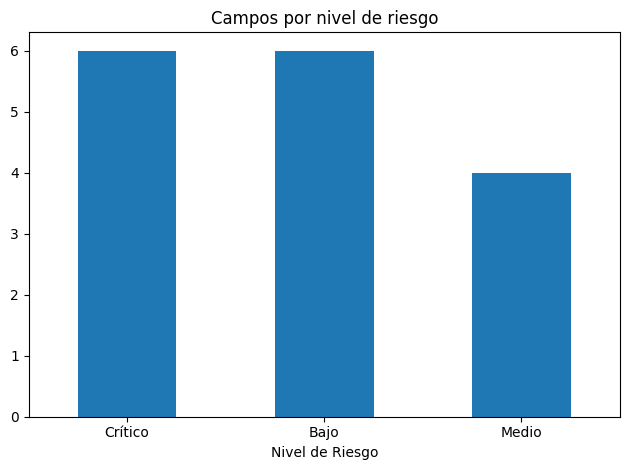

In [10]:
# ==============================
# Gráfico distribución de riesgo
# ==============================

risk_summary.set_index("Nivel de Riesgo")["Cantidad"].plot(
    kind="bar",
    title="Campos por nivel de riesgo"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
# ==============================
# Top campos con mayor riesgo
# ==============================

top_risk_fields = risk_df.sort_values(
    by="Risk Score",
    ascending=False
).head(10)

top_risk_fields

,Campo,Tipo de Dato,Nivel Riesgo,Sensibilidad,Exposicion,Impacto,Probabilidad,Risk Score,Nivel de Riesgo
0,Name,Personal Directo,5.0,5,5,5,4,500,Crítico
3,Blood Type,Dato Sensible,5.0,5,4,5,4,400,Crítico
6,Doctor,Dato Personal,NaN,5,4,5,4,400,Crítico
4,Medical Condition,Dato Sensible,5.0,5,4,5,4,400,Crítico
13,Medication,Dato Sensible,5.0,5,4,5,4,400,Crítico
14,Test Results,Dato Sensible,5.0,5,4,5,4,400,Crítico
2,Gender,Cuasi Identificador,4.0,4,4,4,3,192,Medio
1,Age,Cuasi Identificador,4.0,4,4,4,3,192,Medio
8,Insurance Provider,Dato Financiero,4.0,4,3,4,3,144,Medio
9,Billing Amount,Dato Financiero,4.0,4,3,4,3,144,Medio


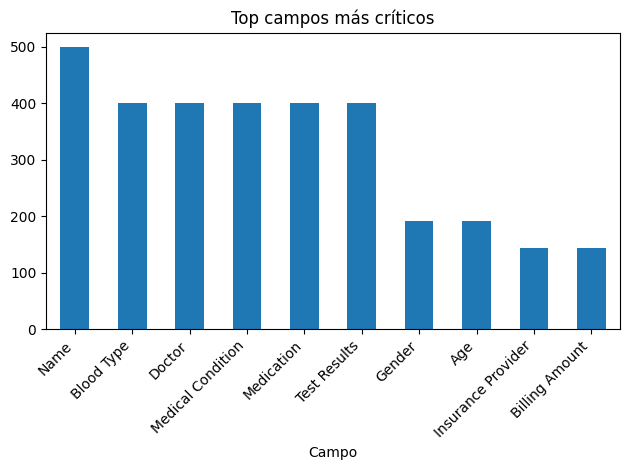

In [12]:
# ==============================
# Gráfico top riesgo
# ==============================

top_risk_fields.set_index("Campo")["Risk Score"].plot(
    kind="bar",
    title="Top campos más críticos"
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [13]:
# ==============================
# Métricas para dashboard
# ==============================

total_fields = len(risk_df)

dashboard_metrics = pd.DataFrame({
    "Metrica": [
        "Total de Campos",
        "Campos Críticos",
        "Campos Alto Riesgo",
        "Campos Medio Riesgo",
        "Campos Bajo Riesgo",
        "Campos Sensibles",
        "Campos Personales",
        "Score Promedio"
    ],
    "Valor": [
        total_fields,
        len(risk_df[risk_df["Nivel de Riesgo"] == "Crítico"]),
        len(risk_df[risk_df["Nivel de Riesgo"] == "Alto"]),
        len(risk_df[risk_df["Nivel de Riesgo"] == "Medio"]),
        len(risk_df[risk_df["Nivel de Riesgo"] == "Bajo"]),
        len(risk_df[risk_df["Tipo de Dato"] == "Dato Sensible"]),
        len(risk_df[risk_df["Tipo de Dato"].isin(["Personal Directo","Dato Personal","Cuasi Identificador"])]),
        round(risk_df["Risk Score"].mean(), 2)
    ]
})

dashboard_metrics

,Metrica,Valor
0,Total de Campos,16.0
1,Campos Críticos,6.0
2,Campos Alto Riesgo,0.0
3,Campos Medio Riesgo,4.0
4,Campos Bajo Riesgo,6.0
5,Campos Sensibles,4.0
6,Campos Personales,4.0
7,Score Promedio,203.5


In [14]:
# ==============================
# Resumen por tipo de dato
# ==============================

type_summary = risk_df.groupby("Tipo de Dato").agg(
    Cantidad=("Campo", "count"),
    Riesgo_Promedio=("Risk Score", "mean")
).reset_index()

type_summary

,Tipo de Dato,Cantidad,Riesgo_Promedio
0,Cuasi Identificador,2,192.0
1,Dato Derivado,1,4.0
2,Dato Financiero,2,144.0
3,Dato Operacional,5,16.0
4,Dato Personal,1,400.0
5,Dato Sensible,4,400.0
6,Personal Directo,1,500.0


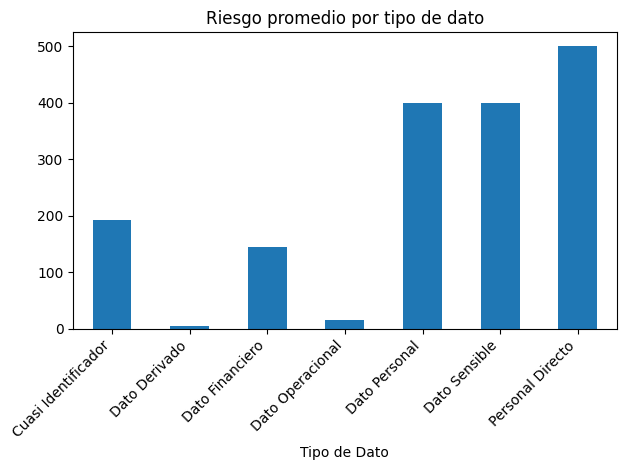

In [15]:
# ==============================
# Gráfico riesgo por tipo
# ==============================

type_summary.set_index("Tipo de Dato")["Riesgo_Promedio"].plot(
    kind="bar",
    title="Riesgo promedio por tipo de dato"
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [16]:
# ==============================
# Recomendaciones
# ==============================

def recomendacion(row):
    if row["Nivel de Riesgo"] == "Crítico":
        return "Anonimización + cifrado + control estricto"
    elif row["Nivel de Riesgo"] == "Alto":
        return "Enmascaramiento + control de acceso"
    elif row["Nivel de Riesgo"] == "Medio":
        return "Control básico + monitoreo"
    else:
        return "Uso controlado"

risk_df["Recomendacion"] = risk_df.apply(recomendacion, axis=1)

risk_df

,Campo,Tipo de Dato,Nivel Riesgo,Sensibilidad,Exposicion,Impacto,Probabilidad,Risk Score,Nivel de Riesgo,Recomendacion
0,Name,Personal Directo,5.0,5,5,5,4,500,Crítico,Anonimización + cifrado + control estricto
1,Age,Cuasi Identificador,4.0,4,4,4,3,192,Medio,Control básico + monitoreo
2,Gender,Cuasi Identificador,4.0,4,4,4,3,192,Medio,Control básico + monitoreo
3,Blood Type,Dato Sensible,5.0,5,4,5,4,400,Crítico,Anonimización + cifrado + control estricto
4,Medical Condition,Dato Sensible,5.0,5,4,5,4,400,Crítico,Anonimización + cifrado + control estricto
5,Date of Admission,Dato Operacional,2.0,2,2,2,2,16,Bajo,Uso controlado
6,Doctor,Dato Personal,NaN,5,4,5,4,400,Crítico,Anonimización + cifrado + control estricto
7,Hospital,Dato Operacional,2.0,2,2,2,2,16,Bajo,Uso controlado
8,Insurance Provider,Dato Financiero,4.0,4,3,4,3,144,Medio,Control básico + monitoreo
9,Billing Amount,Dato Financiero,4.0,4,3,4,3,144,Medio,Control básico + monitoreo


In [17]:
# ==============================
# Guardar resultados
# ==============================

import os
os.makedirs("../data/processed", exist_ok=True)

risk_df.to_csv("../data/processed/risk_scores.csv", index=False)
risk_summary.to_csv("../data/processed/risk_summary.csv", index=False)
dashboard_metrics.to_csv("../data/processed/dashboard_metrics.csv", index=False)
type_summary.to_csv("../data/processed/type_summary.csv", index=False)

print("Archivos generados correctamente")

Archivos generados correctamente


## Conclusiones

- El dataset presenta múltiples campos de alto y crítico riesgo.
- Los datos sensibles representan el mayor nivel de exposición.
- Los datos personales incrementan el riesgo de identificación.
- Se recomienda aplicar anonimización y control de acceso.

Este análisis permite construir un dashboard de privacidad y gobernanza de datos.